In [1]:
# Importing relevant libraries and classes

from simulai.rom._rom import IPOD
from simulai.regression._opinf import OpInf
from simulai.math.integration import LSODA, RK4, ClassWrapper, FunctionWrapper
from simulai.math.differentiation import CollocationDerivative

import math
import numpy as np
import itertools as it
import matplotlib.pyplot as plt
import matplotlib.animation as ani
import h5py
import sys
import optuna


In [2]:
# Basic parameters

n_batches = 30           
n_projected = 3
n_statistics = 100

n_train = 5700       
n_test = 300
n_components = 61

dt = 1e-7

pos = 66048

results_file = "3D_ABL_data.h5"



In [3]:
# Starting the decomposition

ipca = IPOD(config = {"n_components": n_components})

bs = int(n_train/n_batches)
ps = int(n_train/n_projected)
ss = int(n_train/n_statistics)

ind = 0

# Creating empty arrays

n = 0

with h5py.File(results_file, mode = 'r') as file:
        
    p = file['results']['p'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
    u = file['results']['u'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
    v = file['results']['v'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
    w = file['results']['w'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
    
    data = np.array([p,u,v,w])
    
n_variables = data.shape[0]
max_value = np.zeros((n_variables,n_statistics))
min_value = np.zeros((n_variables,n_statistics))
mean_value = np.zeros((n_statistics,data.shape[0],data.shape[2]))
data_norm = np.zeros(data.shape)

# Finding global minimum, global maximum and mean temporal values

for n in range(n_statistics):
    
    with h5py.File(results_file, mode = 'r') as file:
        
        p = file['results']['p'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
        u = file['results']['u'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
        v = file['results']['v'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
        w = file['results']['w'][-n_train-n_test+n*ss:-n_train-n_test+(n+1)*ss,:]
    
        data = np.array([p,u,v,w])
    
    print(f"\nSolving batch: {n+1}")
        
    for i in range(n_variables):
        
        max_value[i,ind] = np.amax(data[i])
        min_value[i,ind] = np.amin(data[i])
    
        data_norm[i] = 2*(data[i] - min_value[i,ind])/(max_value[i,ind] - min_value[i,ind]) - 1
    
#         data_norm[i] = (data[i] - min_value[i,ind])/(max_value[i,ind] - min_value[i,ind])
    
        mean_value[ind,i,:] = np.mean(data_norm[i], axis = 0)
        
    print(f"\nMaximum values (p,u,v,w): {max_value[:,ind]}")
    print(f"\nMinimum values (p,u,v,w): {min_value[:,ind]}") 
    
    ind = ind + 1
    
global_max_value = np.zeros(n_variables)
global_min_value = np.zeros(n_variables)
global_mean_value = np.zeros((data.shape[0],data.shape[2]))

for i in range(n_variables):
    
    global_max_value[i] = np.amax(max_value[i,:])
    global_min_value[i] = np.amin(min_value[i,:])
    global_mean_value[i,:] = np.mean(mean_value[:,i,:], axis = 0)
 

        


Solving batch: 1

Maximum values (p,u,v,w): [1.53799664e+08 3.10280820e+04 1.44630430e+04 1.51414492e+04]

Minimum values (p,u,v,w): [-3.71307520e+08 -1.29191025e+04 -1.08714082e+04 -1.42479043e+04]

Solving batch: 2

Maximum values (p,u,v,w): [1.53053536e+08 3.08543105e+04 1.39188623e+04 1.69465957e+04]

Minimum values (p,u,v,w): [-3.69983904e+08 -1.35116006e+04 -9.23722070e+03 -1.40615781e+04]

Solving batch: 3

Maximum values (p,u,v,w): [1.54611040e+08 3.12545684e+04 1.37000254e+04 1.46351396e+04]

Minimum values (p,u,v,w): [-3.61564032e+08 -1.41939219e+04 -1.16839062e+04 -1.41042637e+04]

Solving batch: 4

Maximum values (p,u,v,w): [1.56239888e+08 3.13127070e+04 1.35520879e+04 1.41165869e+04]

Minimum values (p,u,v,w): [-3.61695712e+08 -1.43595850e+04 -1.16319551e+04 -1.40937188e+04]

Solving batch: 5

Maximum values (p,u,v,w): [1.56484512e+08 3.07488516e+04 1.35156240e+04 1.40388027e+04]

Minimum values (p,u,v,w): [-3.67581472e+08 -1.52287021e+04 -1.17271377e+04 -1.39395879e+04]



Solving batch: 42

Maximum values (p,u,v,w): [1.68908880e+08 3.17953477e+04 1.73393438e+04 1.73312422e+04]

Minimum values (p,u,v,w): [-3.48104352e+08 -1.31957178e+04 -1.71826836e+04 -1.44973184e+04]

Solving batch: 43

Maximum values (p,u,v,w): [1.68427120e+08 3.17623613e+04 1.77581992e+04 1.72265293e+04]

Minimum values (p,u,v,w): [-3.48055328e+08 -1.29092559e+04 -1.41947471e+04 -1.41825527e+04]

Solving batch: 44

Maximum values (p,u,v,w): [1.67197584e+08 3.17321680e+04 1.56243555e+04 1.73500586e+04]

Minimum values (p,u,v,w): [-3.47480608e+08 -1.29991064e+04 -1.29962861e+04 -1.42981211e+04]

Solving batch: 45

Maximum values (p,u,v,w): [1.66627664e+08 3.10015508e+04 1.29043145e+04 1.78962598e+04]

Minimum values (p,u,v,w): [-3.46664672e+08 -1.32339863e+04 -2.44001504e+04 -1.46489854e+04]

Solving batch: 46

Maximum values (p,u,v,w): [1.66059456e+08 3.14168516e+04 1.29406299e+04 1.77291094e+04]

Minimum values (p,u,v,w): [-3.42212960e+08 -1.36615078e+04 -2.47641758e+04 -1.48200732e


Maximum values (p,u,v,w): [1.58746400e+08 3.14419785e+04 1.36568320e+04 1.44803145e+04]

Minimum values (p,u,v,w): [-3.86584608e+08 -1.04205674e+04 -1.41979775e+04 -1.87123379e+04]

Solving batch: 84

Maximum values (p,u,v,w): [1.60411760e+08 3.09453828e+04 1.40451289e+04 1.54859414e+04]

Minimum values (p,u,v,w): [-3.83824320e+08 -1.08629570e+04 -1.37396387e+04 -1.77922637e+04]

Solving batch: 85

Maximum values (p,u,v,w): [1.61257552e+08 3.06382871e+04 1.36272402e+04 1.70593613e+04]

Minimum values (p,u,v,w): [-3.78947296e+08 -1.10992363e+04 -1.29372588e+04 -1.81464414e+04]

Solving batch: 86

Maximum values (p,u,v,w): [1.61323088e+08 3.15579883e+04 1.30325371e+04 1.70947363e+04]

Minimum values (p,u,v,w): [-3.80830912e+08 -1.10497441e+04 -1.52903115e+04 -1.60500029e+04]

Solving batch: 87

Maximum values (p,u,v,w): [1.61141600e+08 3.09301523e+04 1.30377266e+04 1.71810000e+04]

Minimum values (p,u,v,w): [-3.87148896e+08 -9.74148340e+03 -1.77230156e+04 -1.59903203e+04]

Solving batch

In [4]:
# Performing incremental principal component analysis (IPCA)

for n in range(n_batches):

    # Recovering data from hard drive
    
    with h5py.File(results_file, mode = 'r') as file:
        
        p = file['results']['p'][-n_train-n_test+n*bs:-n_train-n_test+(n+1)*bs,:]
        u = file['results']['u'][-n_train-n_test+n*bs:-n_train-n_test+(n+1)*bs,:]
        v = file['results']['v'][-n_train-n_test+n*bs:-n_train-n_test+(n+1)*bs,:]
        w = file['results']['w'][-n_train-n_test+n*bs:-n_train-n_test+(n+1)*bs,:]
    
        data = np.array([p,u,v,w])
        
    print(f"\nSolving batch: {n+1}")
        
    # Pre-processing the data
        
    data_norm = np.zeros(data.shape)
        
    for i in range(n_variables):
        
        data_norm[i] = 2*(data[i] - global_min_value[i])/(global_max_value[i] - global_min_value[i]) - 1
        
#         data_norm[i] = (data[i] - global_min_value[i])/(global_max_value[i] - global_min_value[i])
        
        data_norm[i] = data_norm[i] - global_mean_value[i]
    
    [i,j,k] = data_norm.shape
    data_train = data_norm.reshape(j,i*k)

    # Finding the principal components
    
    ipca.fit(data = data_train)
    
    


Solving batch: 1
Relative Modal Energy 0.9999911980200407

Solving batch: 2
Relative Modal Energy 0.999927718882225

Solving batch: 3
Relative Modal Energy 0.9997632612859156

Solving batch: 4
Relative Modal Energy 0.9993687396457518

Solving batch: 5
Relative Modal Energy 0.9987411576580321

Solving batch: 6
Relative Modal Energy 0.9977545719770103

Solving batch: 7
Relative Modal Energy 0.9966156878723923

Solving batch: 8
Relative Modal Energy 0.9954977464584557

Solving batch: 9
Relative Modal Energy 0.9943400824357694

Solving batch: 10
Relative Modal Energy 0.9931230349469086

Solving batch: 11
Relative Modal Energy 0.9918215461413518

Solving batch: 12
Relative Modal Energy 0.9902745101720355

Solving batch: 13
Relative Modal Energy 0.9887166338457644

Solving batch: 14
Relative Modal Energy 0.9870981451627193

Solving batch: 15
Relative Modal Energy 0.9857502487719919

Solving batch: 16
Relative Modal Energy 0.9846451328516548

Solving batch: 17
Relative Modal Energy 0.9834072

In [5]:
# Performing incremental proper orthogonal decomposition (IPOD) of the training dataset

projected_conc = np.zeros((n_train,n_components))
derivative_conc = np.zeros((n_train,n_components))

data_conc = np.zeros((n_variables,n_train))
reconstructed_origin_conc = np.zeros((n_variables,n_train))

for n in range(n_projected):

    # Recovering data from hard drive
    
    with h5py.File(results_file, mode = 'r') as file:
        
        p = file['results']['p'][-n_train-n_test+n*ps:-n_train-n_test+(n+1)*ps,:]
        u = file['results']['u'][-n_train-n_test+n*ps:-n_train-n_test+(n+1)*ps,:]
        v = file['results']['v'][-n_train-n_test+n*ps:-n_train-n_test+(n+1)*ps,:]
        w = file['results']['w'][-n_train-n_test+n*ps:-n_train-n_test+(n+1)*ps,:]
    
        data = np.array([p,u,v,w])
    
    data_conc[:,n*ps:(n+1)*ps] = data[:,:,pos]
        
    print(f"\nSolving batch: {n+1}")
        
    # Pre-processing the data
        
    data_norm = np.zeros(data.shape)
        
    for i in range(n_variables):
        
        data_norm[i] = 2*(data[i] - global_min_value[i])/(global_max_value[i] - global_min_value[i]) - 1
        
#         data_norm[i] = (data[i] - global_min_value[i])/(global_max_value[i] - global_min_value[i])
        
        data_norm[i] = data_norm[i] - global_mean_value[i]
    
    [i,j,k] = data_norm.shape
    data_train = data_norm.reshape(j,i*k)

    # Projecting train data into the reduced basis and then reconstructing the reduced data

    print("Projecting data into the reduced basis...")
    projected = ipca.project(data = data_train)
    projected_conc[n*ps:(n+1)*ps,:] = projected

    print("Reconstructing the original variables...")
    reconstructed = ipca.reconstruct(projected_data = projected)
        
    # Reconstructing the variables
        
    reconstructed_origin = reconstructed.reshape((i,j,k))
    
    for i in range(n_variables):
        
        reconstructed_origin[i] = ((global_mean_value[i] + reconstructed_origin[i]) + 1)*(global_max_value[i] - global_min_value[i])/2 + global_min_value[i]
        
#         reconstructed_origin[i] = (global_mean_value[i] + reconstructed_origin[i])*(global_max_value[i] - global_min_value[i]) + global_min_value[i]

    reconstructed_origin_conc[:,n*ps:(n+1)*ps] = reconstructed_origin[:,:,pos]

# Finding the derivatives

print("Finding the derivatives...")
diff_config = {'step': dt}
diff_op = CollocationDerivative(config = diff_config)
derivative_conc = diff_op.solve(data = projected_conc)

# Pressure and velocities at the probe location

p_original_train = data_conc[0,:]
p_reconstructed_train = reconstructed_origin_conc[0,:]

u_original_train = data_conc[1,:]
u_reconstructed_train = reconstructed_origin_conc[1,:]

v_original_train = data_conc[2,:]
v_reconstructed_train = reconstructed_origin_conc[2,:]

w_original_train = data_conc[3,:]
w_reconstructed_train = reconstructed_origin_conc[3,:]




Solving batch: 1
Projecting data into the reduced basis...
Reconstructing the original variables...

Solving batch: 2
Projecting data into the reduced basis...
Reconstructing the original variables...

Solving batch: 3
Projecting data into the reduced basis...
Reconstructing the original variables...
Finding the derivatives...
Performing Collocation Derivation.


In [6]:
# Projecting test data in the reduced basis

with h5py.File(results_file, mode = 'r') as file:
        
    p = file['results']['p'][-n_test:,:]
    u = file['results']['u'][-n_test:,:]
    v = file['results']['v'][-n_test:,:]
    w = file['results']['w'][-n_test:,:]
    
    data = np.array([p,u,v,w])
    
data_norm = np.zeros(data.shape)
        
for i in range(n_variables):
        
    data_norm[i] = 2*(data[i] - global_min_value[i])/(global_max_value[i] - global_min_value[i]) - 1
    
#     data_norm[i] = (data[i] - global_min_value[i])/(global_max_value[i] - global_min_value[i])
    
    data_norm[i] = data_norm[i] - global_mean_value[i]
    
[i,j,k] = data_norm.shape
data_test = data_norm.reshape(j,i*k)

print("Projecting data into the reduced basis...")
projected = ipca.project(data = data_test)

print("Reconstructing the original variables...")
reconstructed = ipca.reconstruct(projected_data = projected)

reconstructed_origin = reconstructed.reshape((i,j,k))
    
for i in range(n_variables):
        
    reconstructed_origin[i] = ((global_mean_value[i] + reconstructed_origin[i]) + 1)*(global_max_value[i] - global_min_value[i])/2 + global_min_value[i]
    
#     reconstructed_origin[i] = (global_mean_value[i] + reconstructed_origin[i])*(global_max_value[i] - global_min_value[i]) + global_min_value[i]
         
# Pressure and velocities at the probe location

p_original_test = data[0,:,pos]
p_reconstructed_test = reconstructed_origin[0,:,pos]

u_original_test = data[1,:,pos]
u_reconstructed_test = reconstructed_origin[1,:,pos]

v_original_test = data[2,:,pos]
v_reconstructed_test = reconstructed_origin[2,:,pos]

w_original_test = data[3,:,pos]
w_reconstructed_test = reconstructed_origin[3,:,pos]



Projecting data into the reduced basis...
Reconstructing the original variables...


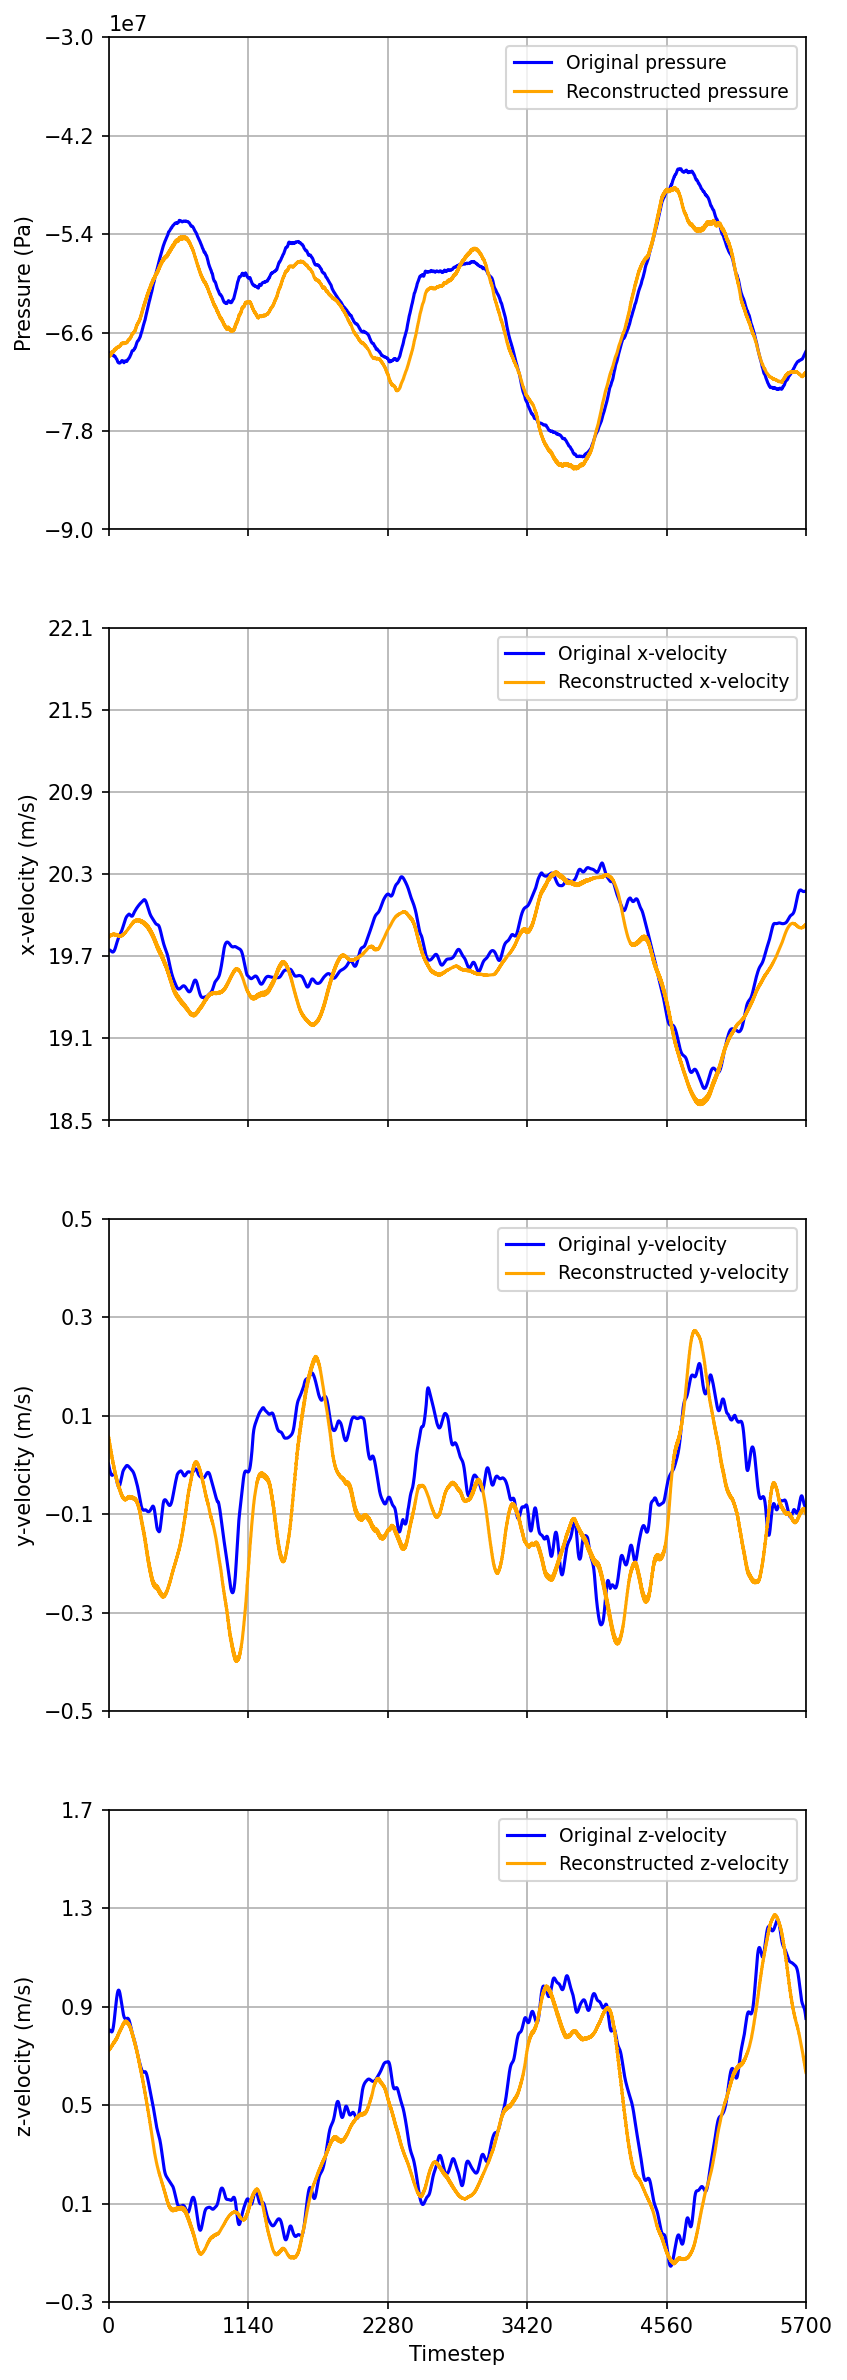

In [7]:
# Graphical analysis - dimensionality reduction effectiveness for training region

fig,axes = plt.subplots(4,1,figsize = (6,20),dpi = 150, sharex = True)

axes[0].plot(p_original_train,color = 'blue',label = "Original pressure")
axes[0].plot(p_reconstructed_train,color = 'orange',label = "Reconstructed pressure")
axes[0].set_ylabel('Pressure (Pa)',fontsize = 10)
axes[0].set_ylim([-9e7,-3e7])
axes[0].set_yticks(np.arange(-9e7,-1.8e7,1.2e7))
axes[0].legend(fontsize = 9)
axes[0].grid(True)

axes[1].plot(u_original_train/1000,color = 'blue',label = "Original x-velocity")
axes[1].plot(u_reconstructed_train/1000,color = 'orange',label = "Reconstructed x-velocity")
axes[1].set_ylabel('x-velocity (m/s)',fontsize = 10)
axes[1].set_ylim([18.5,21.5])
axes[1].set_yticks(np.arange(18.5,22.1,0.6))
axes[1].legend(fontsize = 9)
axes[1].grid(True)

axes[2].plot(v_original_train/1000,color = 'blue',label = "Original y-velocity")
axes[2].plot(v_reconstructed_train/1000,color = 'orange',label = "Reconstructed y-velocity")
axes[2].set_ylabel('y-velocity (m/s)',fontsize = 10)
axes[2].set_ylim([-0.5,0.5])
axes[2].set_yticks(np.arange(-0.5,0.7,0.2))
axes[2].legend(fontsize = 9)
axes[2].grid(True)

axes[3].plot(w_original_train/1000,color = 'blue',label = "Original z-velocity")
axes[3].plot(w_reconstructed_train/1000,color = 'orange',label = "Reconstructed z-velocity")
axes[3].set_xlabel('Timestep',fontsize = 10)
axes[0].set_xlim([0,n_train])
axes[0].set_xticks(np.arange(0,n_train+n_train/5,n_train/5))
axes[3].set_ylabel('z-velocity (m/s)',fontsize = 10)
axes[3].set_ylim([-0.3,1.7])
axes[3].set_yticks(np.arange(-0.3,2.1,0.4))
axes[3].legend(fontsize = 9)
axes[3].grid(True)

# fig.savefig('2D_RB_reconstructed_vs_original(r = 18).jpg',bbox_inches='tight')



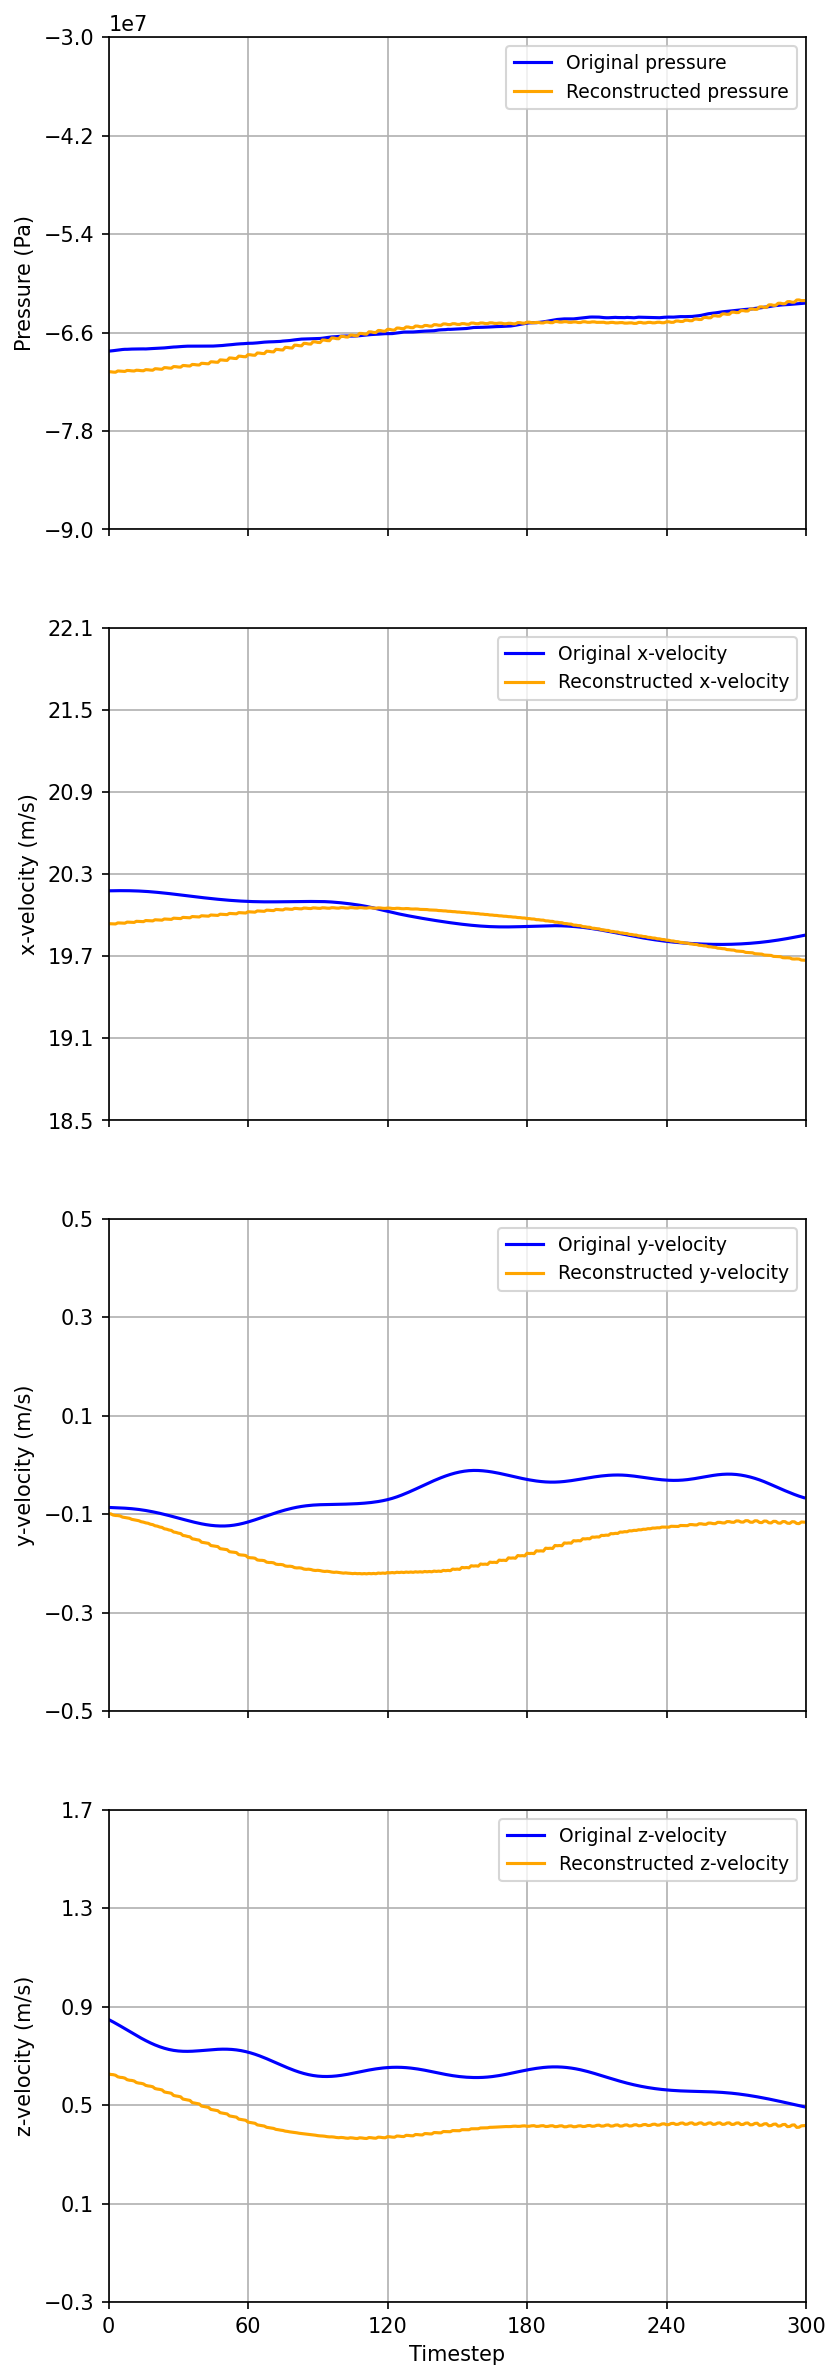

In [8]:
# Graphical analysis - dimensionality reduction effectiveness for testing region

fig,axes = plt.subplots(4,1,figsize = (6,20),dpi = 150, sharex = True)

axes[0].plot(p_original_test,color = 'blue',label = "Original pressure")
axes[0].plot(p_reconstructed_test,color = 'orange',label = "Reconstructed pressure")
axes[0].set_ylabel('Pressure (Pa)',fontsize = 10)
axes[0].set_ylim([-9e7,-3e7])
axes[0].set_yticks(np.arange(-9e7,-1.8e7,1.2e7))
axes[0].legend(fontsize = 9)
axes[0].grid(True)

axes[1].plot(u_original_test/1000,color = 'blue',label = "Original x-velocity")
axes[1].plot(u_reconstructed_test/1000,color = 'orange',label = "Reconstructed x-velocity")
axes[1].set_ylabel('x-velocity (m/s)',fontsize = 10)
axes[1].set_ylim([18.5,21.5])
axes[1].set_yticks(np.arange(18.5,22.1,0.6))
axes[1].legend(fontsize = 9)
axes[1].grid(True)

axes[2].plot(v_original_test/1000,color = 'blue',label = "Original y-velocity")
axes[2].plot(v_reconstructed_test/1000,color = 'orange',label = "Reconstructed y-velocity")
axes[2].set_ylabel('y-velocity (m/s)',fontsize = 10)
axes[2].set_ylim([-0.5,0.5])
axes[2].set_yticks(np.arange(-0.5,0.7,0.2))
axes[2].legend(fontsize = 9)
axes[2].grid(True)

axes[3].plot(w_original_test/1000,color = 'blue',label = "Original z-velocity")
axes[3].plot(w_reconstructed_test/1000,color = 'orange',label = "Reconstructed z-velocity")
axes[3].set_xlabel('Timestep',fontsize = 10)
axes[0].set_xlim([0,n_test])
axes[0].set_xticks(np.arange(0,n_test+n_test/5,n_test/5))
axes[3].set_ylabel('z-velocity (m/s)',fontsize = 10)
axes[3].set_ylim([-0.3,1.7])
axes[3].set_yticks(np.arange(-0.3,2.1,0.4))
axes[3].legend(fontsize = 9)
axes[3].grid(True)

# fig.savefig('2D_RB_reconstructed_vs_original(r = 18).jpg',bbox_inches='tight')

